In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Loading and preparing data
df = pd.read_csv('../data/processed/churn_clean.csv')

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df['EngagementScore'] = df['HourSpendOnApp']*0.4 + df['OrderCount']*0.4 + df['CouponUsed']*0.2
df['IsInactive']      = (df['DaySinceLastOrder'] >= 7).astype(int)
df['IsHighValue']     = (df['CashbackAmount'] >= df['CashbackAmount'].median()).astype(int)
df['ComplainLowSat']  = ((df['Complain'] == 1) & (df['SatisfactionScore'] <= 2)).astype(int)

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = joblib.load('../models/scaler.pkl')
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

# Loading best model
model = joblib.load('../models/best_model.pkl')

print("Setup complete ✓")
print(f"Test set: {X_test_scaled.shape}")

Setup complete ✓
Test set: (1126, 22)


In [3]:
# Creating explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# For Random Forest, shap_values returns list [class0, class1]
# We want class 1 (churn)
shap_vals_churn = shap_values[1]

feature_names = X.columns.tolist()

print("SHAP values generated ✓")
print(f"Shape: {shap_vals_churn.shape}")

SHAP values generated ✓
Shape: (22, 2)


In [7]:
# Extract churn class SHAP values correctly
# shap_values shape is (1126, 22, 2) — take [:, :, 1] for churn class
shap_vals_churn = shap_values[:, :, 1]

print("Fixed shape:", shap_vals_churn.shape)  # should be (1126, 22)

Fixed shape: (1126, 22)


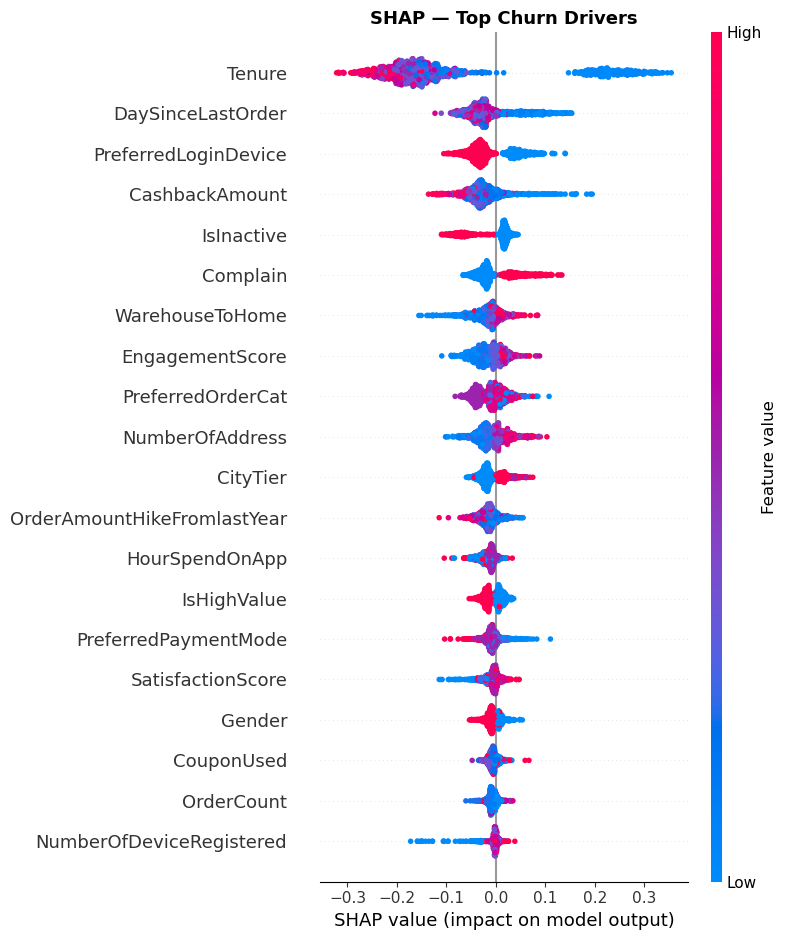

In [9]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_churn,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP — Top Churn Drivers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot_09_shap_summary.png', bbox_inches='tight')
plt.show()

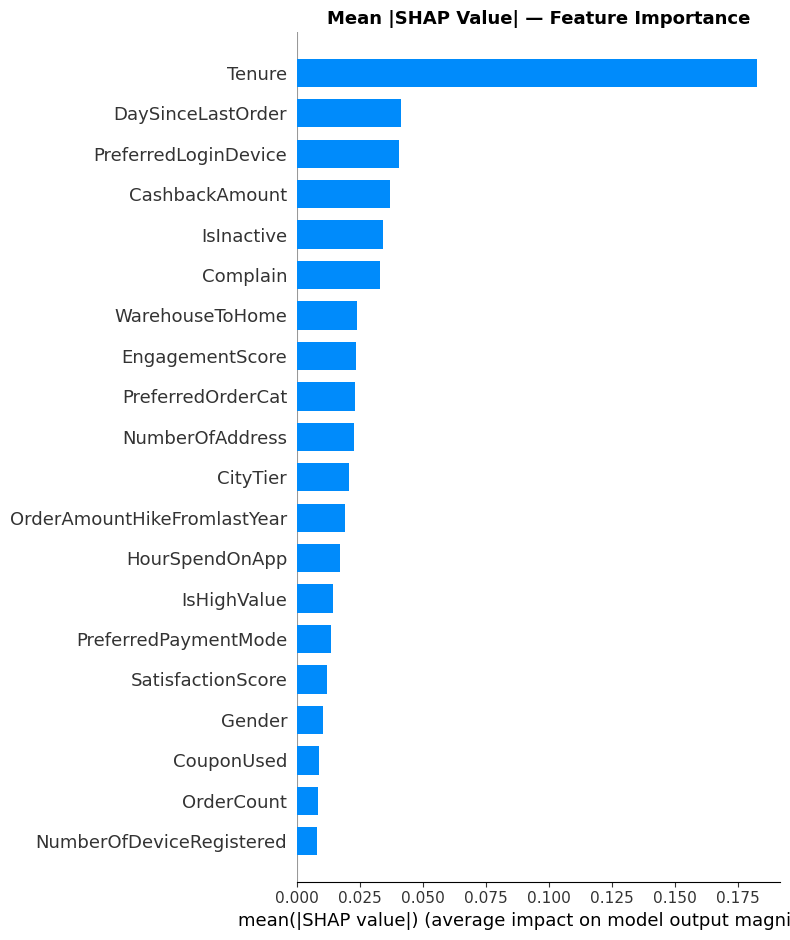

In [11]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_vals_churn,
    X_test_scaled,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP Value| — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot_10_shap_bar.png', bbox_inches='tight')
plt.show()

In [ ]:
## SHAP-Based Business Recommendations

1. TENURE (#1 driver): New customers (0-3 months) are the highest risk.
   → Launch "First 90 Days" onboarding program with weekly check-ins
     and progressive rewards at day 7, 30, 60, and 90.

2. RECENCY (#2 driver): Customers inactive for 7+ days are flagging churn.
   → Trigger automated re-engagement campaign after 5 days of inactivity —
     personalised "We miss you" email with cashback on preferred category.

3. LOGIN DEVICE (#3 driver): Device preference signals engagement pattern.
   → Mobile-only users need a better app experience — invest in
     mobile UX improvements and push notification campaigns.

4. CASHBACK (#4 driver): Low cashback earners churn more.
   → Introduce tiered cashback — customers earning below ₹150/month
     should be auto-upgraded to next cashback tier as retention tool.

5. COMPLAINTS (#6 driver): Complaint filers are high churn risk.
   → Implement 24-hour resolution SLA + proactive follow-up call
     after every complaint — turn a negative into a loyalty moment.